# M1.Ex3: Iris Classification

- Run: [**Open In Colab**](https://colab.research.google.com/github/HassanAlgoz/B5/blob/main/content/W3/M1/exercises/ex3_class.ipynb)
- Dataset:`sklearn.datasets.load_iris()`

In [42]:
import pandas as pd
from sklearn.linear_model import LogisticRegression

![Iris Flowers](https://github.com/HassanAlgoz/B5/blob/main/content/W3/M1/assets/iris_flowers.png?raw=1)

### Step 1.a Load the data

In [24]:
iris = sklearn.datasets.load_iris(as_frame=True)

### Step 2.a Assign variables `X` to the features and `y` to the target

In [25]:
X= iris.data
y=iris.data

### Step 2.b print the type of each

In [26]:
print(type(X))
print(X.dtypes)

<class 'pandas.core.frame.DataFrame'>
sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
dtype: object


In [27]:
print(type(y))
print(y.dtypes)

<class 'pandas.core.frame.DataFrame'>
sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
dtype: object


### Step 2.c identify whether the target is categorical or numerical & whether the task is regression or classification

the target is categorical because it Represents species labels, not a continuous scale.

### Step 3. Identify the number of samples and columns of both the data matrix and the target

In [28]:
# Samples (rows)
n_samples_X = X.shape[0]
n_samples_y = y.shape[0]

# Columns (features)
n_features_X = X.shape[1]

print(f"Data Matrix (X): {n_samples_X} samples and {n_features_X} columns")
print(f"Target vector (y): {n_samples_y} samples and 1 column")

Data Matrix (X): 150 samples and 4 columns
Target vector (y): 150 samples and 1 column


### Step 4. Summarize the distribution of the data (min, max, median, mean, and standard deviation)

In [29]:
print("Summary Statistics for Iris Features:")
X.describe()


Summary Statistics for Iris Features:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [30]:
print("Medians for each feature:")
X.median()

Medians for each feature:


sepal length (cm)    5.80
sepal width (cm)     3.00
petal length (cm)    4.35
petal width (cm)     1.30
dtype: float64

### Step 5. Plot the features to identify separability. Can you see clearly distinguishable groups of points?

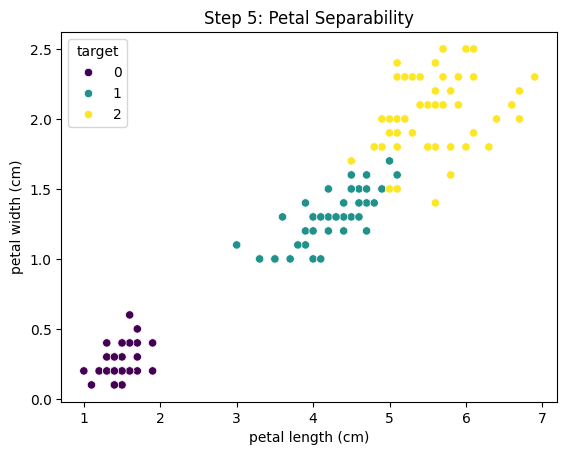

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.scatterplot(x=X['petal length (cm)'], y=X['petal width (cm)'], hue=y, palette='viridis')
plt.title("Step 5: Petal Separability")
plt.show()

### Step 6. Keep the following in "Steps 7" onwards

1. First model will trian on the features: `sepal length (cm)` & `sepal width (cm)`
2. Second model will train on the features: `petal length (cm)` & `petal width (cm)`

Finally, evaluate and compare which of the two feature-sets scored better.

Let's do both subsets now..

### Step 6.a subset the features `sepal length (cm)` & `sepal width (cm)`


In [38]:
X_sepal = X[['sepal length (cm)', 'sepal width (cm)']]
X_sepal

,sepal length (cm),sepal width (cm)
0,5.1,3.5
1,4.9,3.0
2,4.7,3.2
3,4.6,3.1
4,5.0,3.6
...,...,...
145,6.7,3.0
146,6.3,2.5
147,6.5,3.0
148,6.2,3.4


### Step 6.b subset the features `petal length (cm)` & `petal width (cm)`


In [39]:
X_petal = X[['petal length (cm)', 'petal width (cm)']]
X_petal

,petal length (cm),petal width (cm)
0,1.4,0.2
1,1.4,0.2
2,1.3,0.2
3,1.5,0.2
4,1.4,0.2
...,...,...
145,5.2,2.3
146,5.0,1.9
147,5.2,2.0
148,5.4,2.3


### Step 7. Initialize 2 `LogisticRegression` models

In [43]:
model_sepal = LogisticRegression()
model_petal = LogisticRegression()

### Step 8. Split the dataset into train and test sets (remember to stratify by the target to account for class imbalance)

In [44]:
from sklearn.model_selection import train_test_split
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_sepal, y, test_size=0.2, random_state=42, stratify=y
)

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_petal, y, test_size=0.2, random_state=42, stratify=y
)

### Step 9.a Train both models

In [46]:
model_sepal.fit(X_train_s, y_train_s)
model_petal.fit(X_train_p, y_train_p)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


### Step 10. Evaluate and compare both models

In [47]:
score_sepal = model_sepal.score(X_test_s, y_test_s)
score_petal = model_petal.score(X_test_p, y_test_p)

print(f"Accuracy with Sepal features: {score_sepal:.2%}")
print(f"Accuracy with Petal features: {score_petal:.2%}")

Accuracy with Sepal features: 73.33%
Accuracy with Petal features: 96.67%


### Step 11. Which of the two subset of features better distinguishes iris flowers? Can you easily tell?

The Petal subset is better because the groups are clearly separated. The Sepal groups overlap too much, making it hard for a simple model to tell them apart.

### Step 12. Use `DecisionBoundaryDisplay` to plot the learned decision boundary

Text(0.5, 1.0, 'Sepal Decision Boundary (Overlapping)')

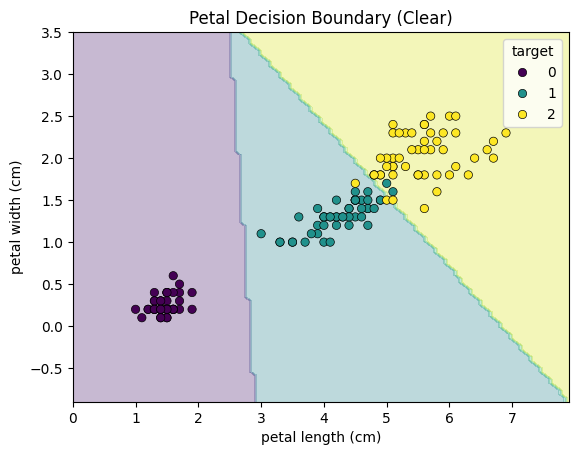

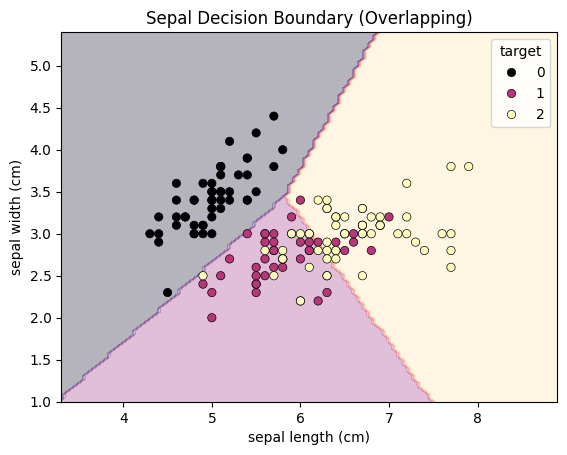

In [48]:
from sklearn.inspection import DecisionBoundaryDisplay

DecisionBoundaryDisplay.from_estimator(model_petal, X_petal, response_method="predict", cmap='viridis', alpha=0.3)
sns.scatterplot(x=X_petal.iloc[:, 0], y=X_petal.iloc[:, 1], hue=y, palette='viridis', edgecolor='k')
plt.title("Petal Decision Boundary (Clear)")


DecisionBoundaryDisplay.from_estimator(model_sepal, X_sepal, response_method="predict", cmap='magma', alpha=0.3)
sns.scatterplot(x=X_sepal.iloc[:, 0], y=X_sepal.iloc[:, 1], hue=y, palette='magma', edgecolor='k')
plt.title("Sepal Decision Boundary (Overlapping)")
